In [27]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl
import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range, _month_iter, _last_business_day_of_month, _n_business_days_before, _nth_business_day_of_month
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

In [29]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
curve_name = "USD-SOFR-1D"
risk_bpv = -100_000

start = datetime.date(2024, 1, 1)
end = datetime.date(2025, 10, 1)

days_pre_month_end = 3
days_after_month_end = 3

cycles = []
for y, m in _month_iter(start, end):
    eom_bd = _last_business_day_of_month(CAL, y, m)
    entry = _n_business_days_before(CAL, eom_bd, days_pre_month_end)

    if m == 12:
        ny, nm = y + 1, 1
    else:
        ny, nm = y, m + 1
    exit_ = _nth_business_day_of_month(CAL, ny, nm, days_after_month_end)

    if entry < start or exit_ > end:
        continue

    tag = f"me-trade-{y:04d}{m:02d}"
    cycles.append((entry, exit_, tag))

In [30]:
triggers = []
for entry_date, exit_date, tag in cycles:
    q = IRSwapQuery(
        structure=IRSwapStructure.FLY,
        value=IRSwapValue.NPV,
        curve=curve_name,
        structure_kwargs={"front_tenor": "5Y", "belly_tenor": "10Y", "back_tenor": "30Y", "bpv": risk_bpv},
        tags=(tag,),
    )
    enter = DateTrigger(DateTriggerRequirements(dates=[entry_date]), actions=[AddQueryAction(query=q)])
    exit_ = DateTrigger(DateTriggerRequirements(dates=[exit_date]), actions=[UnwindPositionsAction(match_tag=tag, fee=0.0)])
    triggers.extend([enter, exit_])

mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=CAL,
        start=min(d for d, _, _ in cycles),
        end=max(e for _, e, _ in cycles),
    )
)

strategy = QueryStrategy(name="Month End Seasonality Backtest", triggers=triggers)
bt = QueryDrivenBacktest(time_grid=tg, mdp=mdp, strategy=strategy)
bt.run()

BACKTESTING...: 100%|██████████| 402/402 [00:10<00:00, 39.71step/s]


Final MTM: 132210.85017244332


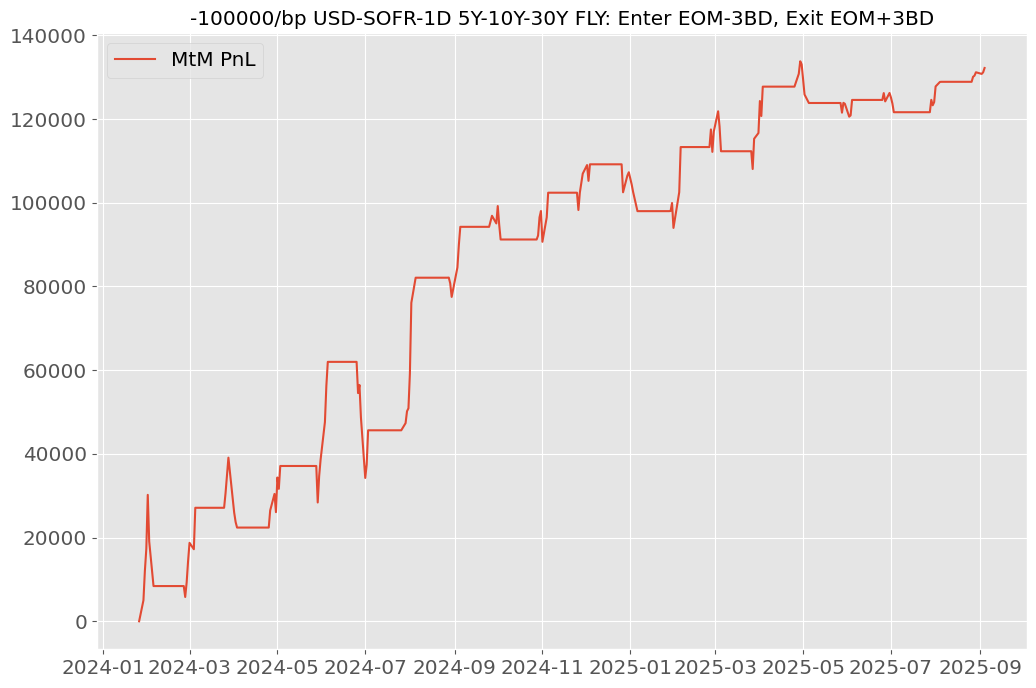

In [31]:
mtm = pd.Series(bt.mtm_history).sort_index()
print("Final MTM:", float(mtm.iloc[-1]))

plt.figure()
plt.plot(mtm.index, mtm.values, label="MtM PnL")
plt.legend()
plt.title(f"{risk_bpv}/bp {q.col_name()[:-4]}: Enter EOM-{days_pre_month_end}BD, Exit EOM+{days_after_month_end}BD")
plt.show()